In [7]:
# install required dependencies
%pip install matplotlib
%pip install --upgrade seaborn

Direct_Bilirubin              0.246273
Total_Bilirubin               0.220218
Alkaline_Phosphotase          0.183363
Albumin and Globulin Ratio    0.163131
Alamine_Aminotransferase      0.163117
Name: Selector, dtype: float64


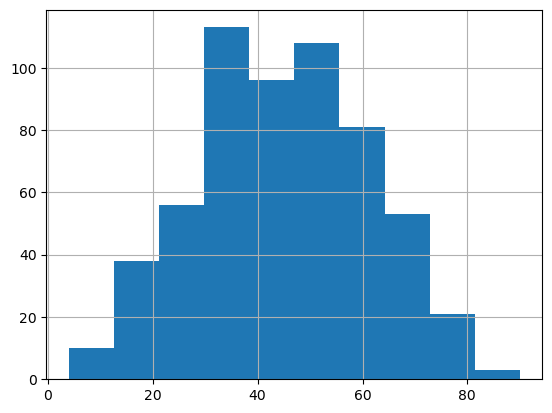

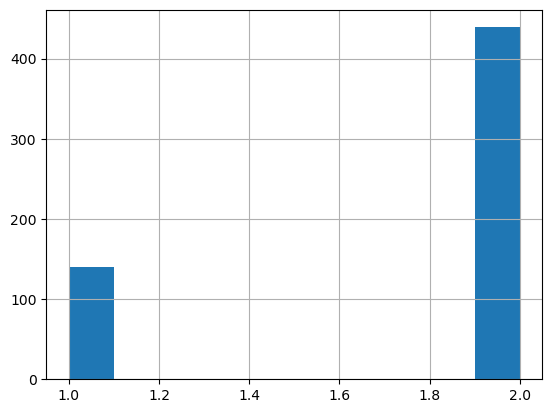

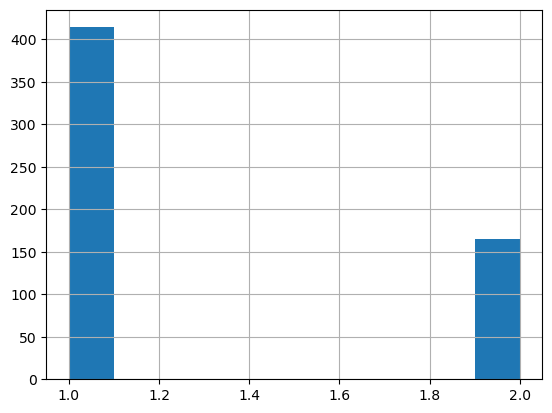

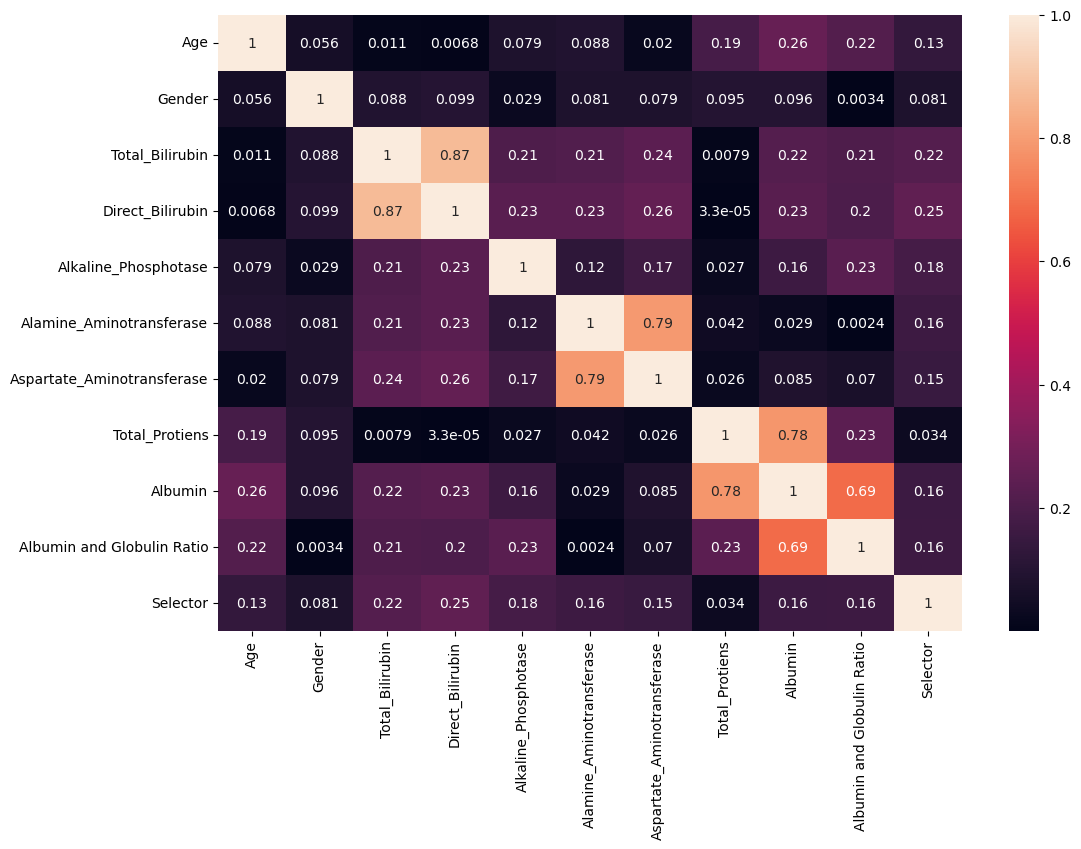

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV data into a pandas data frame
data = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-AI0273EN-SkillsNetwork/labs/v1/m2/data/ILPD.csv')

# Save histograms of data distribution for 'Age', 'Gender', and 'Selector'
plt.figure()
data['Age'].hist()
plt.savefig('age_histogram.png')

plt.figure()
data['Gender'].hist()
plt.savefig('gender_histogram.png')

plt.figure()
data['Selector'].hist()
plt.savefig('selector_histogram.png')

# Save correlation heatmap of the data set
plt.figure(figsize=(12,8))
corr = data.corr()
sns.heatmap(abs(corr), annot=True)
plt.savefig('correlation_heatmap.png', bbox_inches='tight')

# Identify top 5 features with highest absolute correlation with 'Selector'
correlation_with_selector = corr['Selector'].abs().sort_values(ascending=False)
top_5_features = correlation_with_selector[1:6]  
# Exclude 'Selector' itself
print(top_5_features)


In [13]:
import argparse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Tuple


csv_path = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-AI0273EN-SkillsNetwork/labs/v1/m2/data/ILPD.csv'

def load_dataframe(csv_path: str) -> pd.DataFrame:
    try:
        return pd.read_csv(csv_path)
    except Exception as e:
        raise SystemExit(f"Error loading CSV '{csv_path}': {e}")


def plot_histograms(df: pd.DataFrame, hist_path: str) -> None:
    """Plot histograms:
    - Age distribution (overall) by Gender (if present)
    - Age distribution by Selector (if present)
    """
    sns.set(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    if 'Age' in df.columns:
        if 'Gender' in df.columns:
            sns.histplot(data=df, x='Age', hue='Gender', multiple='stack', ax=axes[0])
            axes[0].set_title('Age by Gender')
        else:
            axes[0].text(0.5, 0.5, 'Gender missing', ha='center', va='center')
            axes[0].axis('off')

        if 'Selector' in df.columns:
            sns.histplot(data=df, x='Age', hue='Selector', multiple='stack', ax=axes[1])
            axes[1].set_title('Age by Selector')
        else:
            axes[1].text(0.5, 0.5, 'Selector missing', ha='center', va='center')
            axes[1].axis('off')
    else:
        for ax in axes:
            ax.text(0.5, 0.5, 'Age missing', ha='center', va='center')
            ax.axis('off')

    plt.tight_layout()
    plt.savefig(hist_path)
    plt.close(fig)


def plot_heatmap(df: pd.DataFrame, heatmap_path: str) -> None:
    """Create and save a correlation heatmap using one-hot encoded categoricals."""
    encoded = pd.get_dummies(df, drop_first=False)
    corr = encoded.corr()

    plt.figure(figsize=(12, 10))
    sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.5, square=False)
    plt.tight_layout()
    plt.savefig(heatmap_path)
    plt.close()


def top_features_by_selector(df: pd.DataFrame, top_n: int = 5) -> List[Tuple[str, float]]:
    """Return top_n features with highest absolute correlation to 'Selector'."""
    if 'Selector' not in df.columns:
        return []

    # Numeric Selector: standard Pearson on numeric features
    if pd.api.types.is_numeric_dtype(df['Selector']):
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        if 'Selector' not in numeric_cols:
            numeric_cols.append('Selector')
        sub = df[numeric_cols]
        corr = sub.corr()
        if 'Selector' in corr.columns:
            series = corr['Selector'].abs().drop(labels=['Selector'], errors='ignore')
            top = series.sort_values(ascending=False).head(top_n)
            return [(name, float(val)) for name, val in top.items()]
        return []
    else:
        # Categorical Selector: one-hot encode and compare with any Selector category
        sel = pd.get_dummies(df['Selector'], prefix='Selector')
        others = df.drop(columns=['Selector'])
        enc = pd.get_dummies(others, drop_first=True)
        if enc.shape[1] == 0 or sel.shape[1] == 0:
            return []
        sel, enc = sel.align(enc, join='left', axis=0, fill_value=0)
        combined = pd.concat([enc, sel], axis=1)

        scores: dict = {}
        for feat in enc.columns:
            max_corr = 0.0
            for s_col in sel.columns:
                c = combined[feat].corr(combined[s_col])
                if pd.notnull(c):
                    max_corr = max(max_corr, abs(float(c)))
            scores[feat] = max_corr

        top_items = sorted(scores.items(), key=lambda kv: kv[1], reverse=True)[:top_n]
        return top_items


def save_top_features(items: List[Tuple[str, float]], path: str) -> None:
    with open(path, 'w', encoding='utf-8') as f:
        for name, val in items:
            f.write(f"{name}\t{val:.6f}\n")


def main() -> None:
    parser = argparse.ArgumentParser(description="Compact CSV analysis: histograms, heatmap, and top features.")
    parser.add_argument("csv_path", help="Path to input CSV file (headers in first row)")
    parser.add_argument("hist_path", help="Path to save age distribution histograms image")
    parser.add_argument("heatmap_path", help="Path to save correlation heatmap image")
    parser.add_argument("--top_features_path", default=None, help="Optional path to save top features to file")
    args = parser.parse_args()

    df = load_dataframe(args.csv_path)

    # Histograms
    try:
        plot_histograms(df, args.hist_path)
        print(f"Saved histograms to: {args.hist_path}")
    except Exception as e:
        print(f"Warning: could not create histograms: {e}")

    # Heatmap
    try:
        plot_heatmap(df, args.heatmap_path)
        print(f"Saved heatmap to: {args.heatmap_path}")
    except Exception as e:
        print(f"Warning: could not create heatmap: {e}")

    # Top features
    feats = top_features_by_selector(df, top_n=5)
    if feats:
        print("Top features by absolute correlation with 'Selector':")
        for name, val in feats:
            print(f"  {name}: {val:.6f}")
        if args.top_features_path:
            try:
                save_top_features(feats, args.top_features_path)
                print(f"Saved top features to: {args.top_features_path}")
            except Exception as e:
                print(f"Warning: could not save top features: {e}")
    else:
        print("No top features found (check dataset).")


if __name__ == "__main__":
    main()


usage: ipykernel_launcher.py [-h] [--top_features_path TOP_FEATURES_PATH]
                             csv_path hist_path heatmap_path
ipykernel_launcher.py: error: the following arguments are required: csv_path, hist_path, heatmap_path


SystemExit: 2

c:\Users\Lenovo\anaconda3\Lib\site-packages\IPython\core\interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


Write a brief and compact python code that can perform the following tasks:
1. Perform standard scaling operation on the top 5 attributes identified in the previous code. 
2. Train and test the following classifiers on the data and print a comparative table for their accuracy performance: 
   
   a. Logistic Regression

   b. KNN

   c. Naive Bayes

   d. Decision Trees

   e. Random Forests
   
   f. Multi layer perceptron


In [11]:
import argparse
import numpy as np
import pandas as pd
from typing import List, Tuple

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score


def load_csv(path: str) -> pd.DataFrame:
    try:
        return pd.read_csv(path)
    except Exception as e:
        raise SystemExit(f"Error loading CSV '{path}': {e}")


def compute_top_features(df: pd.DataFrame, top_n: int = 5) -> List[Tuple[str, float]]:
    if 'Selector' not in df.columns:
        return []
    # Numeric Selector: use Pearson correlation on numeric features
    if pd.api.types.is_numeric_dtype(df['Selector']):
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        if 'Selector' not in numeric_cols:
            numeric_cols.append('Selector')
        sub = df[numeric_cols]
        corr = sub.corr()
        if 'Selector' in corr.columns:
            s = corr['Selector'].abs().drop(labels=['Selector'], errors='ignore')
            top = s.sort_values(ascending=False).head(top_n)
            return [(name, float(val)) for name, val in top.items()]
        return []
    else:
        # Categorical Selector: encode and compare with any Selector category
        sel = pd.get_dummies(df['Selector'], prefix='Selector')
        others = df.drop(columns=['Selector'])
        enc = pd.get_dummies(others, drop_first=False)
        if enc.shape[1] == 0 or sel.shape[1] == 0:
            return []
        sel, enc = sel.align(enc, join='left', axis=0, fill_value=0)
        combined = pd.concat([enc, sel], axis=1)

        scores: dict = {}
        for feat in enc.columns:
            max_corr = 0.0
            for s_col in sel.columns:
                c = combined[feat].corr(combined[s_col])
                if pd.notnull(c):
                    max_corr = max(max_corr, abs(float(c)))
            scores[feat] = max_corr
        top_items = sorted(scores.items(), key=lambda kv: kv[1], reverse=True)[:top_n]
        return top_items


def main():
    parser = argparse.ArgumentParser(description="Scale top-5 features and evaluate classifiers.")
    parser.add_argument("csv_path", help="Path to input CSV file (headers in first row)")
    args = parser.parse_args()

    df = load_csv(args.csv_path)

    if 'Selector' not in df.columns:
        print("Selector column not found; exiting.")
        return

    # One-hot encode features (excluding target)
    X_raw = df.drop(columns=['Selector'])
    X_enc = pd.get_dummies(X_raw, drop_first=False)
    X_enc = X_enc.fillna(0.0)
    # Target encoding
    y = df['Selector'].astype(str)
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    if len(np.unique(y_enc)) < 2:
        print("Not enough classes in Selector for classification.")
        return

    # Identify and scale top-5 features
    top_feats = compute_top_features(df, top_n=5)
    top_names = [name for name, _ in top_feats]
    cols_to_scale = [c for c in top_names if c in X_enc.columns]
    if cols_to_scale:
        from sklearn.preprocessing import StandardScaler
        scaler = StandardScaler()
        X_enc[cols_to_scale] = scaler.fit_transform(X_enc[cols_to_scale])

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_enc, y_enc, test_size=0.2, random_state=42, stratify=y_enc
    )

    models = [
        ("Logistic Regression", LogisticRegression(max_iter=1000, solver='lbfgs', multi_class='multinomial')),
        ("KNN", KNeighborsClassifier()),
        ("Naive Bayes", GaussianNB()),
        ("Decision Tree", DecisionTreeClassifier()),
        ("Random Forest", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
        ("MLP", MLPClassifier(hidden_layer_sizes=(100,), max_iter=300))
    ]

    print("Model\tAccuracy")
    for name, model in models:
        try:
            model.fit(X_train, y_train)
            preds = model.predict(X_test)
            acc = accuracy_score(y_test, preds)
            print(f"{name}\t{acc:.3f}")
        except Exception as e:
            print(f"{name}\tError: {e}")


if __name__ == "__main__":
    main()


usage: ipykernel_launcher.py [-h] csv_path
ipykernel_launcher.py: error: the following arguments are required: csv_path


SystemExit: 2